## **Terrorist Attack Type Prediction using Machine Learning**

## **Objective**

The objective is to predict the type of terrorist attack using features such as target type, weapon type, and country. This is a multi-class classification problem, where supervised machine learning models are used to learn patterns from historical data and classify different types of attacks.


In [ ]:
# Load data
import pandas as pd
df = pd.read_csv(
    "Global Terrorism Data.csv",
    encoding='latin1',
    on_bad_lines='skip',
    engine='python'
)

## **Exploratory Data Analysis**

EDA was performed to understand patterns in attack types, targets, and weapon usage. The analysis helped identify important features for prediction.

## **1. Target vs Attack (relationship)**
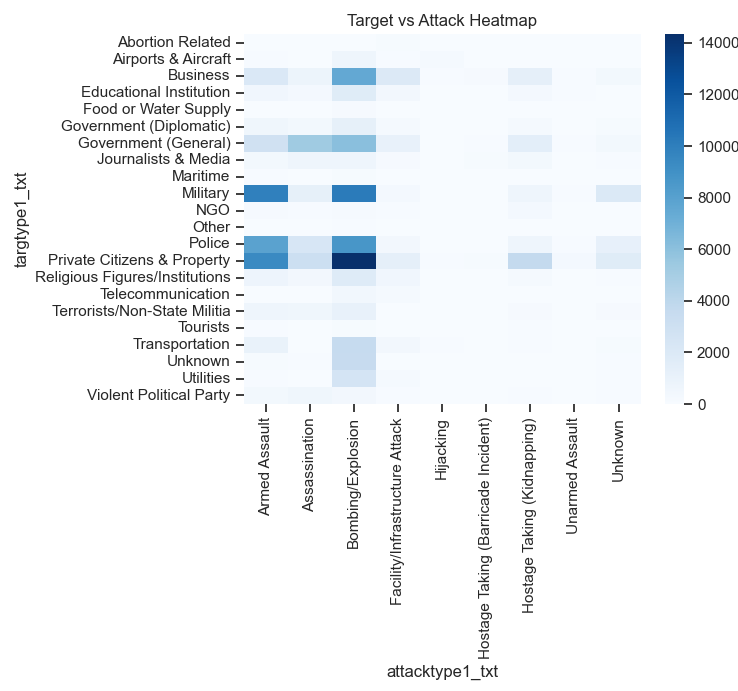

## **2. Attack Type Distribution**
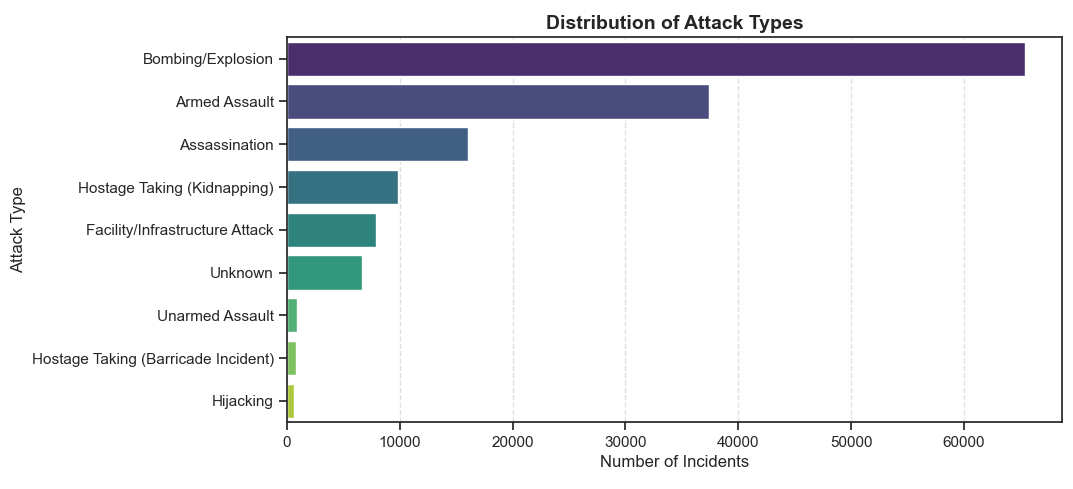

## **3. Weapon Type Distribution**
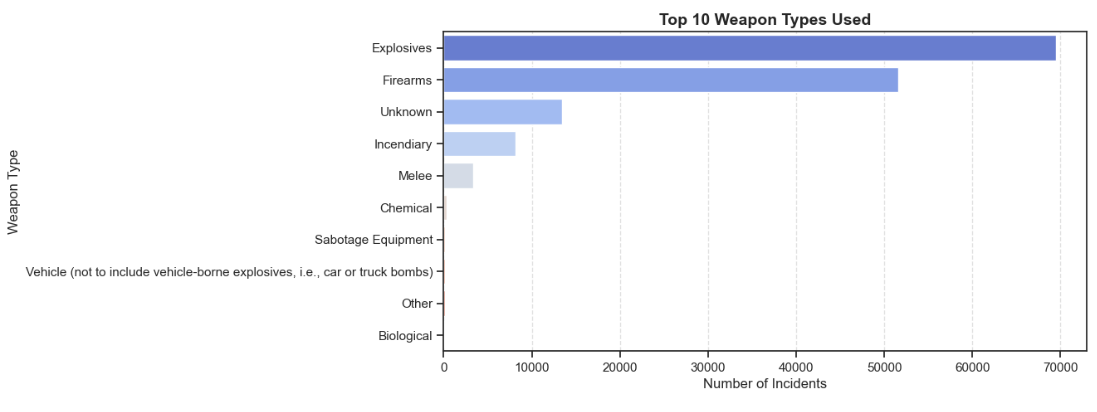

## **Data Preprocessing**

The dataset was cleaned by handling missing values and selecting relevant features. Categorical variables were converted into numerical format using One-Hot Encoding.

In [ ]:
# Select Features & Target
features = ['country_txt', 'targtype1_txt', 'weaptype1_txt']
target = 'attacktype1_txt'

df = df[features + [target]].dropna()

X = df[features]
y = df[target]

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features)
    ]
)

## **Model Building**

Multiple supervised learning models were used, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

In [ ]:
# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

## **Model Evaluation**

The models were evaluated based on their accuracy to compare performance.

In [ ]:
# Train & Compare

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8048
Decision Tree Accuracy: 0.8110
Random Forest Accuracy: 0.8161
Gradient Boosting Accuracy: 0.8053


In [ ]:
# Final Comparison

print("\nFinal Comparison:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")


Final Comparison:
Logistic Regression: 0.7964
Decision Tree: 0.8087
Random Forest: 0.8069
Gradient Boosting: 0.8055


## **Results & Comparison**
All models performed similarly with accuracy around 80%. Decision Tree achieved the highest accuracy, but Random Forest is preferred due to its better generalization and reduced overfitting. Gradient Boosting showed competitive performance, while Logistic Regression performed slightly lower due to its linear assumptions.

In [ ]:
# Classification Report for Best Model (Random Forest)
from sklearn.metrics import classification_report

# Refit pipeline for Random Forest
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

print("=== CLASSIFICATION REPORT (Random Forest) ===")
print(classification_report(y_test, y_pred_best))

=== CLASSIFICATION REPORT (Random Forest) ===
                                     precision    recall  f1-score   support

                      Armed Assault       0.58      0.57      0.57       254
                      Assassination       0.74      0.67      0.70       411
                  Bombing/Explosion       0.94      0.98      0.96       862
     Facility/Infrastructure Attack       0.84      0.91      0.87       206
                          Hijacking       0.62      0.71      0.67        14
Hostage Taking (Barricade Incident)       0.75      0.39      0.51        31
        Hostage Taking (Kidnapping)       0.76      0.69      0.72       100
                    Unarmed Assault       0.00      0.00      0.00         2
                            Unknown       0.50      0.61      0.55        56

                           accuracy                           0.82      1936
                          macro avg       0.64      0.61      0.62      1936
                       weigh

In [ ]:
# Feature Importance
import pandas as pd
import numpy as np

# Get feature names after OneHotEncoding
ohe = best_pipeline.named_steps['preprocessor']
feature_names = ohe.get_feature_names_out(features)

# Get importance from Random Forest
rf_model = best_pipeline.named_steps['classifier']
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

print("=== TOP 15 FEATURE IMPORTANCE ===")
print(importance_df)

=== TOP 15 FEATURE IMPORTANCE ===
                                            Feature  Importance
130                   cat__weaptype1_txt_Explosives    0.292090
132                     cat__weaptype1_txt_Firearms    0.164765
133                   cat__weaptype1_txt_Incendiary    0.126291
138                      cat__weaptype1_txt_Unknown    0.076976
97                  cat__country_txt_United Kingdom    0.030717
109                     cat__targtype1_txt_Business    0.019513
98                   cat__country_txt_United States    0.017253
120  cat__targtype1_txt_Private Citizens & Property    0.016013
113         cat__targtype1_txt_Government (General)    0.013580
62                       cat__country_txt_Nicaragua    0.011383
119                       cat__targtype1_txt_Police    0.009620
116                     cat__targtype1_txt_Military    0.009501
43                           cat__country_txt_Italy    0.009029
108          cat__targtype1_txt_Airports & Aircraft    0.008723
18    

In [ ]:
# Save all outputs for Power BI

# 1. Model comparison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy %': [round(v * 100, 2) for v in results.values()]
}).sort_values('Accuracy %', ascending=False)

results_df.to_csv('model_comparison.csv', index=False)
print("✅ model_comparison.csv saved!")

# 2. Actual vs Predicted
actual_vs_predicted = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best
})
actual_vs_predicted.to_csv('actual_vs_predicted.csv', index=False)
print("✅ actual_vs_predicted.csv saved!")

# 3. Feature importance
importance_df.to_csv('feature_importance.csv', index=False)
print("✅ feature_importance.csv saved!")

# 4. Attack type distribution
attack_dist = df['attacktype1_txt'].value_counts().reset_index()
attack_dist.columns = ['Attack Type', 'Count']
attack_dist.to_csv('attack_distribution.csv', index=False)
print("✅ attack_distribution.csv saved!")

✅ model_comparison.csv saved!
✅ actual_vs_predicted.csv saved!
✅ feature_importance.csv saved!
✅ attack_distribution.csv saved!


In [ ]:
from google.colab import files

files.download('model_comparison.csv')
files.download('actual_vs_predicted.csv')
files.download('feature_importance.csv')
files.download('attack_distribution.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>